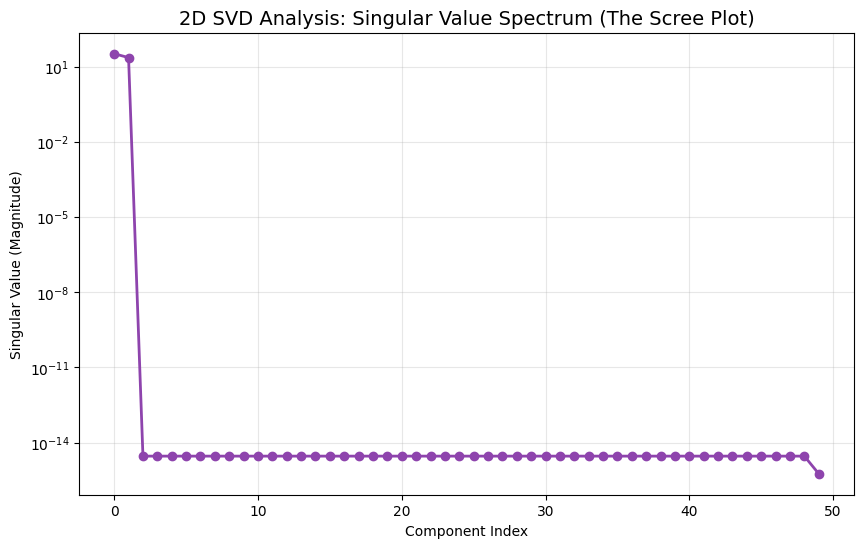

✅ 3D Asset saved: ../../../assets\60_svd_3d.png


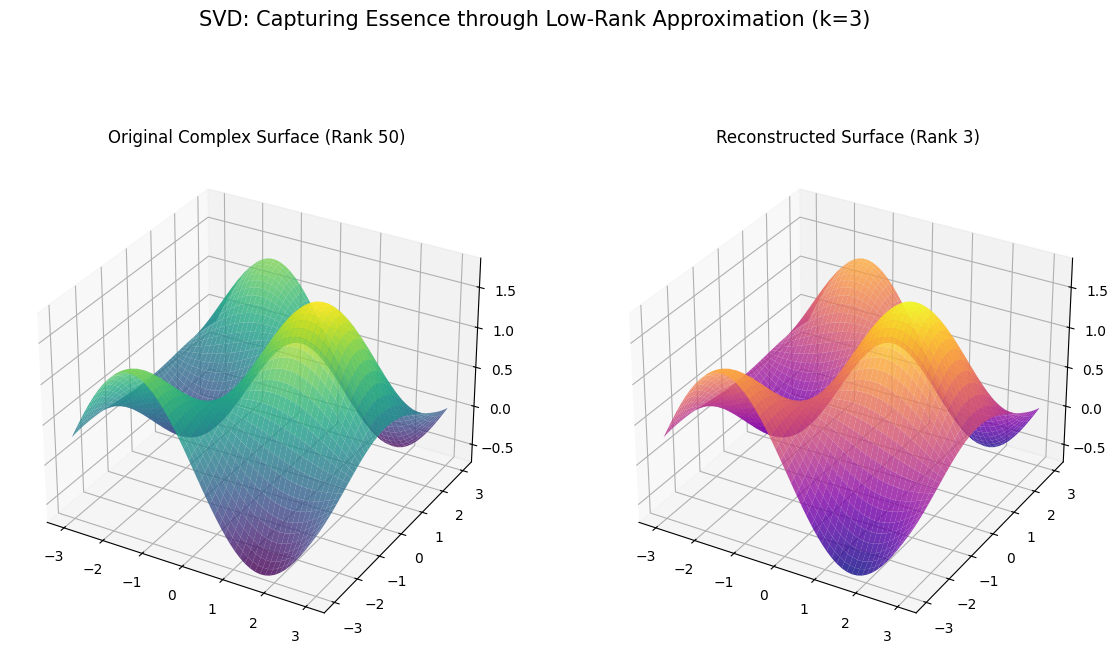

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def run_svd_master():
    # --- PROFESSIONAL PATH SETUP (Relative Path) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Create a Complex 2D Surface (represented as a matrix)
    x = np.linspace(-3, 3, 50)
    y = np.linspace(-3, 3, 50)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(X) * np.cos(Y) + np.exp(-0.1 * (X**2 + Y**2)) # Complex math surface

    # 2. Perform Singular Value Decomposition
    U, s, Vt = np.linalg.svd(Z)
    S = np.zeros(Z.shape)
    np.fill_diagonal(S, s)

    # --- 📸 ASSET 1: SINGULAR VALUE DECAY (60_svd_2d.png) ---
    plt.figure(figsize=(10, 6))
    plt.plot(s, 'o-', color='#8e44ad', lw=2)
    plt.title("2D SVD Analysis: Singular Value Spectrum (The Scree Plot)", fontsize=14)
    plt.xlabel("Component Index"); plt.ylabel("Singular Value (Magnitude)")
    plt.yscale('log') # Log scale to see the decay better
    plt.grid(alpha=0.3, which='both')
    
    save_path_2d = os.path.join(asset_path, '60_svd_2d.png')
    plt.savefig(save_path_2d, dpi=300)
    plt.show()

    # --- 📸 ASSET 2: LOW-RANK RECONSTRUCTION (60_svd_3d.png) ---
    fig = plt.figure(figsize=(14, 8))
    
    # Original Surface
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    ax1.set_title("Original Complex Surface (Rank 50)")

    # Reconstruct using only top K components
    k = 3
    Z_approx = U[:, :k] @ S[:k, :k] @ Vt[:k, :]
    
    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(X, Y, Z_approx, cmap='plasma', alpha=0.8)
    ax2.set_title(f"Reconstructed Surface (Rank {k})")

    plt.suptitle(f"SVD: Capturing Essence through Low-Rank Approximation (k={k})", fontsize=15)
    
    save_path_3d = os.path.join(asset_path, '60_svd_3d.png')
    plt.savefig(save_path_3d, dpi=300)
    print(f"✅ 3D Asset saved: {save_path_3d}")
    plt.show()

if __name__ == "__main__":
    run_svd_master()